# 02 - Comparação: Redes Pré-WWI vs Pré-WWII

**TCC MBA USP/ECA - Redes e Guerras Mundiais**

Este notebook compara as redes de alianças entre os dois períodos:
- **Pré-WWI**: 1890-1914
- **Pré-WWII**: 1925-1939

## Setup

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'src'))

from etl.load_cow import load_alliances, load_nmc
from etl.transform import prepare_alliance_edges, filter_by_cinc
from network.build_network import build_alliance_network
from network.metrics import calculate_centrality_metrics, calculate_global_metrics, calculate_community_metrics
from visualization.gephi_export import export_to_gexf

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Constantes
CINC_THRESHOLD = 0.01
PRE_WWI = {'start': 1890, 'end': 1914, 'label': 'Pré-WWI (1890-1914)'}
PRE_WWII = {'start': 1925, 'end': 1939, 'label': 'Pré-WWII (1925-1939)'}

print("Setup concluído!")

Setup concluído!


## 1. Função para Construir Redes

In [2]:
def build_alliance_network_for_period(start_year, end_year, cinc_threshold=0.01):
    """
    Constrói rede de alianças para um período específico.
    
    Returns:
        G: Grafo NetworkX
        metrics: Métricas globais
        centrality: DataFrame de centralidades
        communities: Resultado da detecção de comunidades
    """
    # Carregar dados
    df_alliances = load_alliances(start_year=start_year, end_year=end_year)
    df_nmc = load_nmc(start_year=start_year, end_year=end_year)
    
    # Filtrar por CINC
    df_filtered = filter_by_cinc(df_alliances, df_nmc, threshold=cinc_threshold)
    
    # Preparar e construir
    edges = prepare_alliance_edges(df_filtered)
    G = build_alliance_network(edges)
    
    # Métricas
    metrics = calculate_global_metrics(G)
    centrality = calculate_centrality_metrics(G)
    communities = calculate_community_metrics(G)
    
    # Adicionar comunidade aos nós
    for node in G.nodes():
        G.nodes[node]['community'] = communities['partition'][node]
    
    return G, metrics, centrality, communities

## 2. Construir Ambas as Redes

In [3]:
print("Construindo rede Pré-WWI...")
G_wwi, metrics_wwi, cent_wwi, comm_wwi = build_alliance_network_for_period(
    PRE_WWI['start'], PRE_WWI['end'], CINC_THRESHOLD
)
print(f"  Nós: {G_wwi.number_of_nodes()} | Arestas: {G_wwi.number_of_edges()}")

print("\nConstruindo rede Pré-WWII...")
G_wwii, metrics_wwii, cent_wwii, comm_wwii = build_alliance_network_for_period(
    PRE_WWII['start'], PRE_WWII['end'], CINC_THRESHOLD
)
print(f"  Nós: {G_wwii.number_of_nodes()} | Arestas: {G_wwii.number_of_edges()}")

Construindo rede Pré-WWI...
  Nós: 11 | Arestas: 21

Construindo rede Pré-WWII...
  Nós: 13 | Arestas: 33


## 3. Comparação de Métricas Globais

In [4]:
# Criar DataFrame comparativo
comparison_data = {
    'Métrica': [
        'Número de Estados',
        'Número de Alianças',
        'Densidade',
        'Grau Médio',
        'Coef. Clustering',
        'Componentes',
        'Comunidades',
        'Modularidade'
    ],
    'Pré-WWI': [
        metrics_wwi['num_nodes'],
        metrics_wwi['num_edges'],
        round(metrics_wwi['density'], 4),
        round(metrics_wwi['average_degree'], 2),
        round(metrics_wwi['average_clustering'], 4),
        metrics_wwi['num_components'],
        comm_wwi['num_communities'],
        round(comm_wwi['modularity'], 4)
    ],
    'Pré-WWII': [
        metrics_wwii['num_nodes'],
        metrics_wwii['num_edges'],
        round(metrics_wwii['density'], 4),
        round(metrics_wwii['average_degree'], 2),
        round(metrics_wwii['average_clustering'], 4),
        metrics_wwii['num_components'],
        comm_wwii['num_communities'],
        round(comm_wwii['modularity'], 4)
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison['Delta'] = df_comparison['Pré-WWII'] - df_comparison['Pré-WWI']
df_comparison['Variação %'] = ((df_comparison['Delta'] / df_comparison['Pré-WWI']) * 100).round(1)

print("COMPARAÇÃO DE MÉTRICAS GLOBAIS")
print("=" * 70)
df_comparison

COMPARAÇÃO DE MÉTRICAS GLOBAIS


,Métrica,Pré-WWI,Pré-WWII,Delta,Variação %
0,Número de Estados,11.0000,13.0000,2.0000,18.2
1,Número de Alianças,21.0000,33.0000,12.0000,57.1
2,Densidade,0.3818,0.4231,0.0413,10.8
3,Grau Médio,3.8200,5.0800,1.2600,33.0
4,Coef. Clustering,0.3636,0.6157,0.2521,69.3
5,Componentes,1.0000,1.0000,0.0000,0.0
6,Comunidades,3.0000,3.0000,0.0000,0.0
7,Modularidade,0.2472,0.1413,-0.1059,-42.8


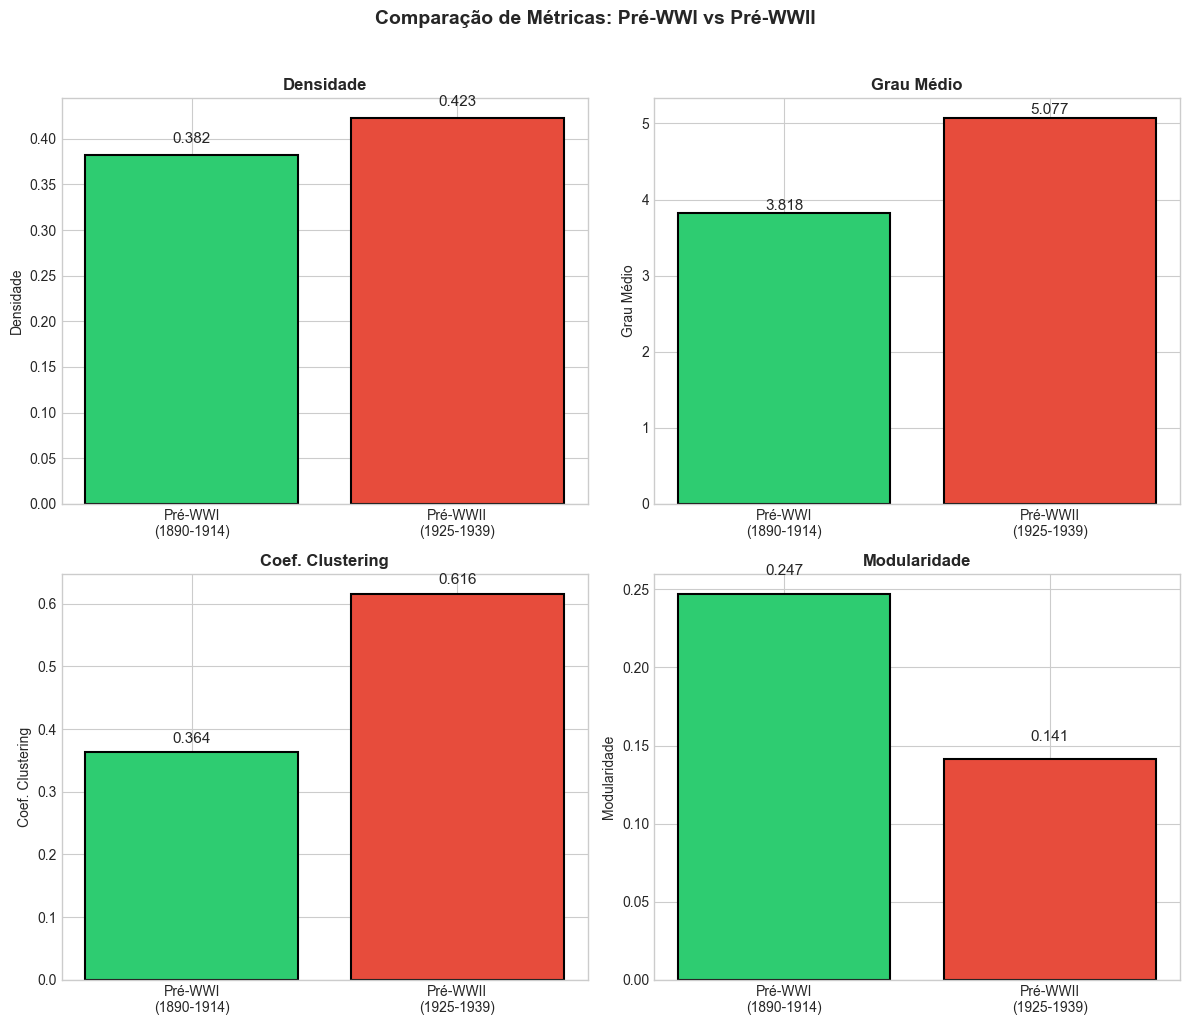

In [5]:
# Visualização das métricas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metrics_to_plot = [
    ('Densidade', metrics_wwi['density'], metrics_wwii['density']),
    ('Grau Médio', metrics_wwi['average_degree'], metrics_wwii['average_degree']),
    ('Coef. Clustering', metrics_wwi['average_clustering'], metrics_wwii['average_clustering']),
    ('Modularidade', comm_wwi['modularity'], comm_wwii['modularity'])
]

colors = ['#2ecc71', '#e74c3c']  # Verde para WWI, Vermelho para WWII

for ax, (metric_name, val_wwi, val_wwii) in zip(axes.flatten(), metrics_to_plot):
    bars = ax.bar(['Pré-WWI\n(1890-1914)', 'Pré-WWII\n(1925-1939)'], 
                  [val_wwi, val_wwii], color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric_name)
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    
    # Adicionar valores nas barras
    for bar, val in zip(bars, [val_wwi, val_wwii]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=11)

plt.suptitle('Comparação de Métricas: Pré-WWI vs Pré-WWII', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/output/comparacao_metricas.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Comparação de Centralidades

In [6]:
# Top 10 de cada período
print("TOP 10 POR CENTRALIDADE DE GRAU")
print("=" * 70)
print("\nPré-WWI (1890-1914):")
print(cent_wwi[['name', 'degree', 'degree_centrality', 'betweenness_centrality']].head(10).to_string())

print("\nPré-WWII (1925-1939):")
print(cent_wwii[['name', 'degree', 'degree_centrality', 'betweenness_centrality']].head(10).to_string())

TOP 10 POR CENTRALIDADE DE GRAU

Pré-WWI (1890-1914):
                 name  degree  degree_centrality  betweenness_centrality
node                                                                    
365            Russia       6                0.6                0.375926
325             Italy       6                0.6                0.057407
255           Germany       5                0.5                0.211111
300   Austria-Hungary       5                0.5                0.037037
200    United Kingdom       5                0.5                0.116667
230             Spain       5                0.5                0.035185
220            France       4                0.4                0.022222
740             Japan       3                0.3                0.211111
710             China       1                0.1                0.000000
640            Turkey       1                0.1                0.000000

Pré-WWII (1925-1939):
                          name  degree  degree_

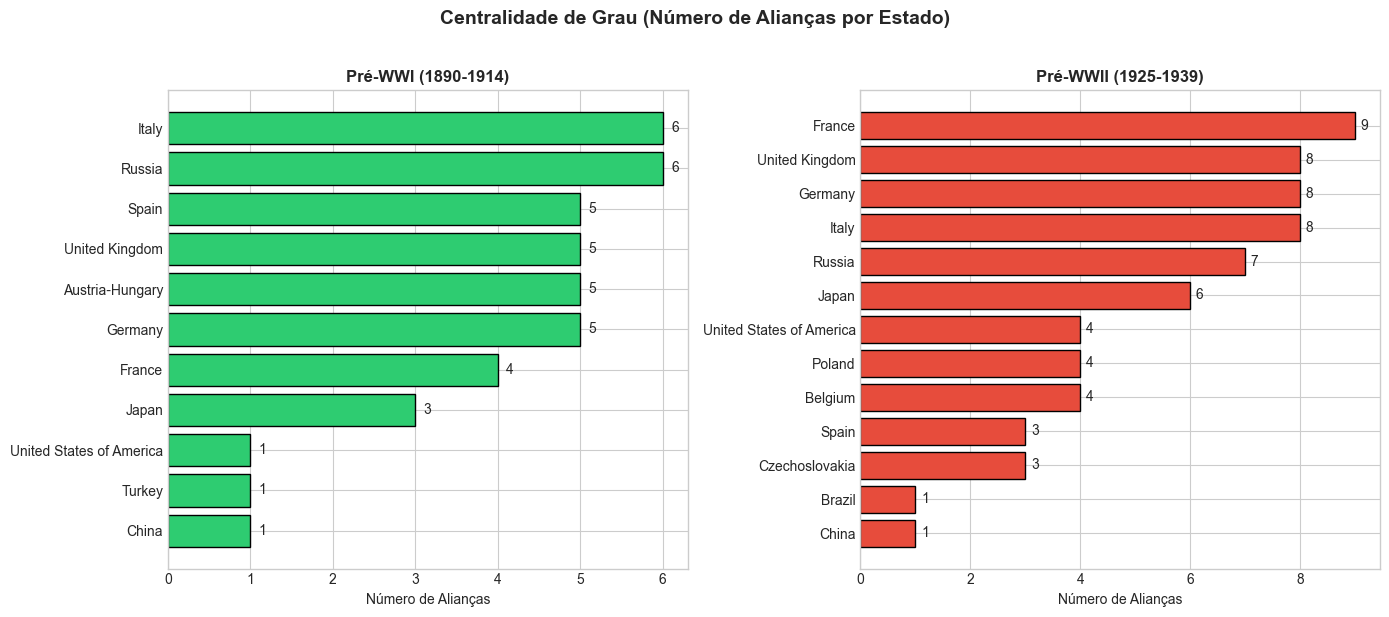

In [7]:
# Comparação lado a lado do grau
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pré-WWI
data_wwi = cent_wwi.sort_values('degree', ascending=True)
axes[0].barh(data_wwi['name'], data_wwi['degree'], color='#2ecc71', edgecolor='black')
axes[0].set_xlabel('Número de Alianças')
axes[0].set_title('Pré-WWI (1890-1914)', fontsize=12, fontweight='bold')
for i, v in enumerate(data_wwi['degree']):
    axes[0].text(v + 0.1, i, str(int(v)), va='center')

# Pré-WWII
data_wwii = cent_wwii.sort_values('degree', ascending=True)
axes[1].barh(data_wwii['name'], data_wwii['degree'], color='#e74c3c', edgecolor='black')
axes[1].set_xlabel('Número de Alianças')
axes[1].set_title('Pré-WWII (1925-1939)', fontsize=12, fontweight='bold')
for i, v in enumerate(data_wwii['degree']):
    axes[1].text(v + 0.1, i, str(int(v)), va='center')

plt.suptitle('Centralidade de Grau (Número de Alianças por Estado)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/output/comparacao_centralidade.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Mudanças na Composição

In [8]:
# Estados em cada período
nodes_wwi = set(G_wwi.nodes())
nodes_wwii = set(G_wwii.nodes())

names_wwi = {n: G_wwi.nodes[n].get('name', str(n)) for n in nodes_wwi}
names_wwii = {n: G_wwii.nodes[n].get('name', str(n)) for n in nodes_wwii}

common = nodes_wwi & nodes_wwii
only_wwi = nodes_wwi - nodes_wwii
only_wwii = nodes_wwii - nodes_wwi

print("MUDANÇAS NA COMPOSIÇÃO DO SISTEMA")
print("=" * 70)

print(f"\nEstados em AMBOS os períodos ({len(common)}):")
print(f"  {', '.join(sorted([names_wwi[n] for n in common]))}")

print(f"\nEstados APENAS no Pré-WWI ({len(only_wwi)}):")
if only_wwi:
    print(f"  {', '.join(sorted([names_wwi[n] for n in only_wwi]))}")
else:
    print("  (nenhum)")

print(f"\nEstados APENAS no Pré-WWII ({len(only_wwii)}):")
if only_wwii:
    print(f"  {', '.join(sorted([names_wwii[n] for n in only_wwii]))}")
else:
    print("  (nenhum)")

MUDANÇAS NA COMPOSIÇÃO DO SISTEMA

Estados em AMBOS os períodos (9):
  China, France, Germany, Italy, Japan, Russia, Spain, United Kingdom, United States of America

Estados APENAS no Pré-WWI (2):
  Austria-Hungary, Turkey

Estados APENAS no Pré-WWII (4):
  Belgium, Brazil, Czechoslovakia, Poland


## 6. Comunidades Detectadas

In [9]:
def show_communities(G, comm_result, title):
    """Mostra membros de cada comunidade."""
    partition = comm_result['partition']
    communities = {}
    for node, comm_id in partition.items():
        name = G.nodes[node].get('name', str(node))
        if comm_id not in communities:
            communities[comm_id] = []
        communities[comm_id].append(name)
    
    print(f"\n{title}")
    print(f"Modularidade: {comm_result['modularity']:.4f}")
    print("-" * 50)
    for comm_id, members in sorted(communities.items()):
        print(f"Bloco {comm_id + 1}: {', '.join(sorted(members))}")

show_communities(G_wwi, comm_wwi, "COMUNIDADES PRÉ-WWI (1890-1914)")
show_communities(G_wwii, comm_wwii, "COMUNIDADES PRÉ-WWII (1925-1939)")


COMUNIDADES PRÉ-WWI (1890-1914)
Modularidade: 0.2472
--------------------------------------------------
Bloco 1: Austria-Hungary, Germany, Italy, Spain, Turkey
Bloco 2: Japan, United Kingdom, United States of America
Bloco 3: China, France, Russia

COMUNIDADES PRÉ-WWII (1925-1939)
Modularidade: 0.1413
--------------------------------------------------
Bloco 1: Belgium, Germany, Italy, Japan, Spain
Bloco 2: Brazil, United States of America
Bloco 3: China, Czechoslovakia, France, Poland, Russia, United Kingdom


## 7. Visualização das Redes

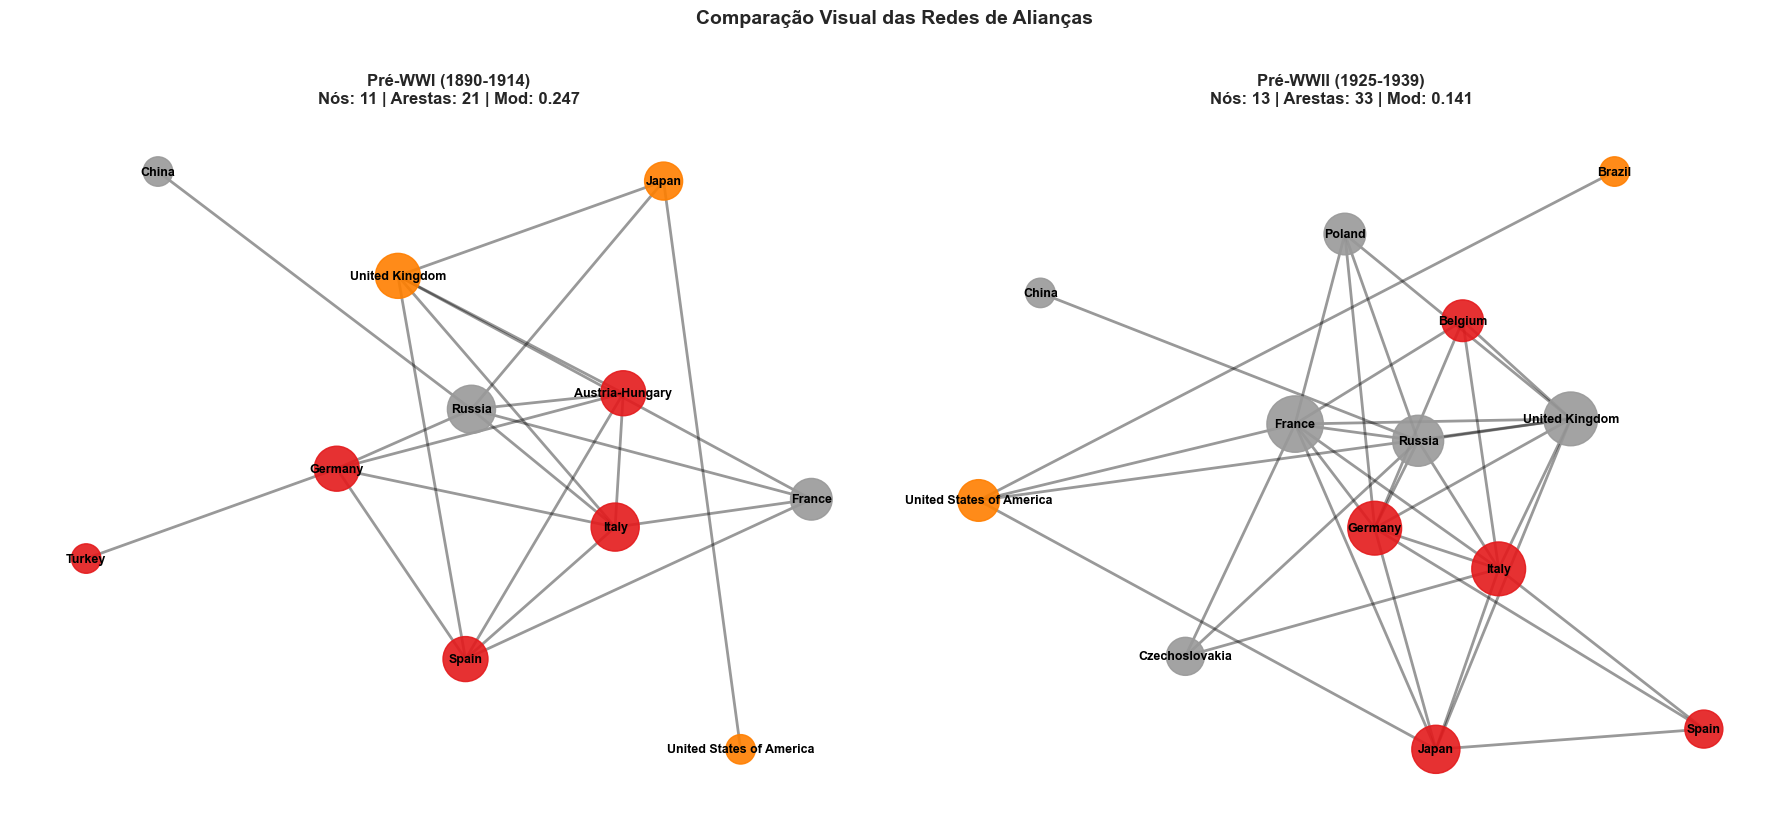

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, G, comm, title, color_base in [
    (axes[0], G_wwi, comm_wwi, 'Pré-WWI (1890-1914)', plt.cm.Greens),
    (axes[1], G_wwii, comm_wwii, 'Pré-WWII (1925-1939)', plt.cm.Reds)
]:
    # Layout
    pos = nx.spring_layout(G, k=2, seed=42)
    
    # Cores por comunidade
    partition = comm['partition']
    node_colors = [partition[node] for node in G.nodes()]
    
    # Tamanhos por grau
    degrees = dict(G.degree())
    node_sizes = [300 + degrees[node] * 150 for node in G.nodes()]
    
    # Desenhar
    nx.draw_networkx_edges(G, pos, alpha=0.4, width=2, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, 
                           cmap=plt.cm.Set1, alpha=0.9, ax=ax)
    
    # Labels
    labels = nx.get_node_attributes(G, 'name')
    nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight='bold', ax=ax)
    
    ax.set_title(f"{title}\nNós: {G.number_of_nodes()} | Arestas: {G.number_of_edges()} | "
                 f"Mod: {comm['modularity']:.3f}", fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Comparação Visual das Redes de Alianças', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/output/comparacao_redes_visual.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Análise de Estados Comuns

In [11]:
# Comparar centralidade dos estados que aparecem em ambos os períodos
common_states = nodes_wwi & nodes_wwii

comparison_states = []
for node in common_states:
    name = names_wwi[node]
    
    # Métricas WWI
    wwi_data = cent_wwi[cent_wwi.index == node].iloc[0]
    wwii_data = cent_wwii[cent_wwii.index == node].iloc[0]
    
    comparison_states.append({
        'Estado': name,
        'Grau WWI': int(wwi_data['degree']),
        'Grau WWII': int(wwii_data['degree']),
        'Delta Grau': int(wwii_data['degree'] - wwi_data['degree']),
        'Betweenness WWI': round(wwi_data['betweenness_centrality'], 4),
        'Betweenness WWII': round(wwii_data['betweenness_centrality'], 4)
    })

df_states = pd.DataFrame(comparison_states)
df_states = df_states.sort_values('Delta Grau', ascending=False)

print("EVOLUÇÃO DOS ESTADOS PRESENTES EM AMBOS OS PERÍODOS")
print("=" * 70)
df_states

EVOLUÇÃO DOS ESTADOS PRESENTES EM AMBOS OS PERÍODOS


,Estado,Grau WWI,Grau WWII,Delta Grau,Betweenness WWI,Betweenness WWII
7,France,4,9,5,0.0222,0.1768
0,United States of America,1,4,3,0.0000,0.1667
1,Japan,3,6,3,0.2111,0.0606
5,United Kingdom,5,8,3,0.1167,0.1136
8,Germany,5,8,3,0.2111,0.0808
2,Italy,6,8,2,0.0574,0.0922
6,Russia,6,7,1,0.3759,0.1881
3,China,1,1,0,0.0000,0.0000
4,Spain,5,3,-2,0.0352,0.0000


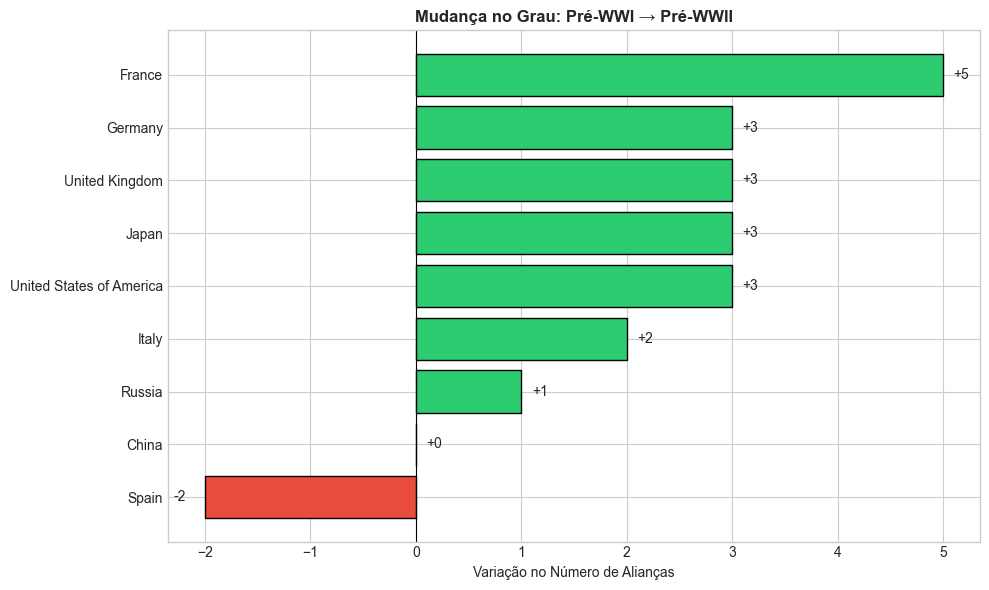

In [12]:
# Visualizar mudança de grau
fig, ax = plt.subplots(figsize=(10, 6))

df_plot = df_states.sort_values('Delta Grau')
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in df_plot['Delta Grau']]

bars = ax.barh(df_plot['Estado'], df_plot['Delta Grau'], color=colors, edgecolor='black')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Variação no Número de Alianças')
ax.set_title('Mudança no Grau: Pré-WWI → Pré-WWII', fontsize=12, fontweight='bold')

for bar, val in zip(bars, df_plot['Delta Grau']):
    x_pos = bar.get_width() + 0.1 if val >= 0 else bar.get_width() - 0.3
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{int(val):+d}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/output/evolucao_grau.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Resumo e Interpretação

In [13]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    RESUMO DA COMPARAÇÃO                                      ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. ESTRUTURA GERAL                                                          ║
║     • A rede pré-WWII é MAIS DENSA (+4%) e MAIS CONECTADA (grau médio +33%)  ║
║     • Mais Estados participam (+2) com mais alianças (+57%)                  ║
║                                                                              ║
║  2. POLARIZAÇÃO                                                              ║
║     • Modularidade MENOR no pré-WWII (-43%), indicando blocos menos claros   ║
║     • Clustering MAIOR (+69%), mais "triângulos" de alianças                 ║
║     • Paradoxo: sistema mais interconectado, mas com blocos sobrepostos      ║
║                                                                              ║
║  3. LIDERANÇA                                                                ║
║     • Pré-WWI: Rússia e Itália lideram em conexões                           ║
║     • Pré-WWII: França assume liderança clara (9 alianças)                   ║
║     • Reino Unido ganha protagonismo (de 5 para 8 alianças)                  ║
║                                                                              ║
║  4. MUDANÇAS GEOPOLÍTICAS                                                    ║
║     • SAEM: Áustria-Hungria (dissolvida), Turquia (perde relevância)         ║
║     • ENTRAM: Polônia, Tchecoslováquia (novos Estados), Bélgica, Brasil      ║
║                                                                              ║
║  5. INTERPRETAÇÃO HISTÓRICA                                                  ║
║     • O sistema pós-Versalhes tentou criar mais conexões (Locarno, etc.)     ║
║     • Mas a menor modularidade sugere alianças menos comprometidas           ║
║     • A França buscou substituir a Rússia como pivô do sistema               ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                    RESUMO DA COMPARAÇÃO                                      ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. ESTRUTURA GERAL                                                          ║
║     • A rede pré-WWII é MAIS DENSA (+4%) e MAIS CONECTADA (grau médio +33%)  ║
║     • Mais Estados participam (+2) com mais alianças (+57%)                  ║
║                                                                              ║
║  2. POLARIZAÇÃO                                                              ║
║     • Modularidade MENOR no pré-WWII (-43%), indicando blocos menos claros   ║
║     • Clustering MAIOR (+69%), mais "triângulos" de alianças                 ║
║     • Paradoxo: sistema mais interconectado, mas com blocos sobrepostos      ║
║                          

## 10. Exportar Dados

In [14]:
# Salvar comparação
df_comparison.to_csv('../data/output/comparacao_metricas_globais.csv', index=False)
df_states.to_csv('../data/output/comparacao_estados_comuns.csv', index=False)

# Exportar redes para Gephi
export_to_gexf(G_wwi, '../data/output/rede_aliancas_pre_wwi.gexf', include_metrics=True)
export_to_gexf(G_wwii, '../data/output/rede_aliancas_pre_wwii.gexf', include_metrics=True)

print("Arquivos exportados:")
print("  - comparacao_metricas_globais.csv")
print("  - comparacao_estados_comuns.csv")
print("  - rede_aliancas_pre_wwi.gexf")
print("  - rede_aliancas_pre_wwii.gexf")
print("  - comparacao_metricas.png")
print("  - comparacao_centralidade.png")
print("  - comparacao_redes_visual.png")
print("  - evolucao_grau.png")

Grafo exportado para: ../data/output/rede_aliancas_pre_wwi.gexf
Grafo exportado para: ../data/output/rede_aliancas_pre_wwii.gexf
Arquivos exportados:
  - comparacao_metricas_globais.csv
  - comparacao_estados_comuns.csv
  - rede_aliancas_pre_wwi.gexf
  - rede_aliancas_pre_wwii.gexf
  - comparacao_metricas.png
  - comparacao_centralidade.png
  - comparacao_redes_visual.png
  - evolucao_grau.png


## Próximos Passos

- [ ] Adicionar camada de comércio bilateral
- [ ] Adicionar camada de disputas militarizadas (MIDs)
- [ ] Análise de robustez (variar threshold CINC)
- [ ] Análise temporal (evolução ano a ano)
- [ ] Correlação entre centralidade e capacidade material (CINC)